# 05 - Mushroom Stacking Ensemble

**Auteur:** Brent Van Gelder  
**Dataset:** `mushroom_project_dataset.csv`  
**Doel:** de sterke punten van verschillende modellen combineren om zowel accuracy als herkenning van giftige paddenstoelen te verbeteren.

> Dit is een onderwijsmodel en mag nooit worden gebruikt om echte paddenstoelen veilig te verklaren.

Deze notebook gebruikt exact dezelfde brondata, uitgesloten ruiskolommen, seed 42, 70/15/15-split en evaluatiemetrics als de afzonderlijke modelnotebooks. De testset blijft vergrendeld.

## 1. Technologie en architectuur

Een `StackingClassifier` combineert vier basismodellen:

- de eerder gekozen getunede Random Forest;
- de baseline Histogram Gradient Boosting;
- Extra Trees voor extra boomdiversiteit;
- Logistic Regression als lineair perspectief.

Het meta-model is opnieuw Logistic Regression. Het leert uitsluitend uit out-of-fold voorspellingen van de trainingsset, zodat het geen voorspellingen ziet van basismodellen die op dezelfde rijen zijn getraind.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## 2. Data laden en vaste instellingen

Dezelfde controles en keuzes als in de andere notebooks worden toegepast. De twee expliciete `jumbled_noise`-kolommen worden verwijderd. Ontbrekende numerieke waarden krijgen binnen iedere pipeline de trainingsmediaan; categorische ontbrekende waarden krijgen de expliciete categorie `__missing__`.

In [2]:
RANDOM_STATE = 42
DATA_PATH = Path("mushroom_project_dataset.csv")
TARGET = "class"
EDIBLE_LABEL = "e"
POISONOUS_LABEL = "p"
RUN_FINAL_TEST = False

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset niet gevonden: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)
if TARGET not in df.columns:
    raise ValueError(f"Doelkolom '{TARGET}' ontbreekt.")
if df[TARGET].isna().any():
    raise ValueError("De doelkolom bevat ontbrekende waarden.")
if set(df[TARGET].unique()) != {EDIBLE_LABEL, POISONOUS_LABEL}:
    raise ValueError(f"Onverwachte labels: {set(df[TARGET].unique())}")

noise_columns = [column for column in df.columns if column.startswith("jumbled_noise_")]
model_df = df.drop(columns=noise_columns).copy()

summary = pd.DataFrame({
    "datatype": model_df.dtypes.astype(str),
    "ontbrekend": model_df.isna().sum(),
    "ontbrekend_percentage": (100 * model_df.isna().mean()).round(1),
    "unieke_waarden": model_df.nunique(dropna=True),
}).sort_values("ontbrekend_percentage", ascending=False)

print(f"Rijen: {len(model_df):,}")
print(f"Exact dubbele rijen na verwijderen van ruis: {model_df.duplicated().sum()}")
print(f"Uitgesloten ruiskolommen: {noise_columns}")
display(model_df[TARGET].value_counts().rename_axis("klasse").to_frame("aantal"))
display(summary)

Rijen: 5,000
Exact dubbele rijen na verwijderen van ruis: 5
Uitgesloten ruiskolommen: ['jumbled_noise_0', 'jumbled_noise_1']


,aantal
klasse,
e,3107
p,1893


,datatype,ontbrekend,ontbrekend_percentage,unieke_waarden
spore-print-color,object,4740,94.8,7
stem-surface,object,3359,67.2,8
cap-diameter,float64,2032,40.6,1238
stem-height,float64,1013,20.3,1086
habitat,object,1004,20.1,8
gill-color,object,989,19.8,12
season,object,973,19.5,4
ring-type,object,577,11.5,8
cap-shape,object,406,8.1,7
stem-width,float64,395,7.9,2221


## 3. Dezelfde train-, validatie- en testset

De tweestapssplit met dezelfde seed levert exact dezelfde 70% trainingsrijen, 15% validatierijen en 15% testrijen als de andere notebooks. Alleen training wordt gebruikt om de basis- en metamodelparameters te leren.

In [3]:
X = model_df.drop(columns=TARGET)
y = model_df[TARGET]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

split_summary = pd.DataFrame({
    "rijen": [len(X_train), len(X_validation), len(X_test)],
    "aandeel_dataset": [len(X_train) / len(X), len(X_validation) / len(X), len(X_test) / len(X)],
    "aandeel_giftig": [
        (y_train == POISONOUS_LABEL).mean(),
        (y_validation == POISONOUS_LABEL).mean(),
        (y_test == POISONOUS_LABEL).mean(),
    ],
}, index=["train", "validatie", "test"])
display(split_summary.style.format({
    "aandeel_dataset": "{:.1%}",
    "aandeel_giftig": "{:.1%}",
}))

,rijen,aandeel_dataset,aandeel_giftig
train,3500,70.0%,37.9%
validatie,750,15.0%,37.9%
test,750,15.0%,37.9%


## 4. Lekvrije pipelines voor de basismodellen

Elk basismodel krijgt een eigen preprocessingpipeline. Hierdoor worden imputatie en one-hot encoding opnieuw binnen iedere stacking-fold geleerd. Logistic Regression krijgt daarnaast standaardisatie; boommodellen hebben die niet nodig.

In [4]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

def make_preprocessor(scale_numeric=False):
    numeric_steps = [
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    return ColumnTransformer([
        ("numeric", Pipeline(numeric_steps), numeric_features),
        ("categorical", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="__missing__")),
            ("one_hot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), categorical_features),
    ], verbose_feature_names_out=False)

random_forest_pipeline = Pipeline([
    ("preprocessor", make_preprocessor()),
    ("classifier", RandomForestClassifier(
        n_estimators=500,
        max_depth=18,
        min_samples_split=10,
        min_samples_leaf=4,
        max_features="sqrt",
        max_samples=0.9,
        class_weight={0: 1.0, 1: 3.0},
        random_state=RANDOM_STATE,
        n_jobs=1,
    )),
])

gradient_boosting_pipeline = Pipeline([
    ("preprocessor", make_preprocessor()),
    ("classifier", HistGradientBoostingClassifier(
        learning_rate=0.08,
        max_iter=300,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        l2_regularization=0.1,
        class_weight="balanced",
        early_stopping=True,
        validation_fraction=0.15,
        random_state=RANDOM_STATE,
    )),
])

extra_trees_pipeline = Pipeline([
    ("preprocessor", make_preprocessor()),
    ("classifier", ExtraTreesClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=1,
    )),
])

logistic_pipeline = Pipeline([
    ("preprocessor", make_preprocessor(scale_numeric=True)),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=3000,
        solver="lbfgs",
        random_state=RANDOM_STATE,
    )),
])

## 5. Stacking trainen

Voor iedere trainingsrij worden de meta-features met vijfvoudige gestratificeerde out-of-fold voorspellingen gemaakt. Het meta-model ziet vier kansen: één van elk basismodel. Daarna worden de basismodellen opnieuw op de volledige trainingsset gefit voor latere voorspellingen.

In [5]:
stacking_cv = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=RANDOM_STATE
)

stacking_ensemble = StackingClassifier(
    estimators=[
        ("random_forest", random_forest_pipeline),
        ("gradient_boosting", gradient_boosting_pipeline),
        ("extra_trees", extra_trees_pipeline),
        ("logistic_regression", logistic_pipeline),
    ],
    final_estimator=LogisticRegression(
        C=1.0,
        max_iter=3000,
        solver="lbfgs",
        random_state=RANDOM_STATE,
    ),
    cv=stacking_cv,
    stack_method="predict_proba",
    passthrough=False,
    n_jobs=-1,
)

stacking_ensemble.fit(X_train, y_train)
print("Stacking ensemble getraind op de trainingsset.")

Stacking ensemble getraind op de trainingsset.


## 6. Evaluatiefunctie

De giftige klasse `p` is de positieve klasse. Naast accuracy meten we balanced accuracy, precision, recall, F1, F2, ROC-AUC en average precision. Een instelbare drempel maakt de afweging tussen accuracy en veiligheid zichtbaar.

In [6]:
def evaluate_classifier(fitted_model, X_eval, y_eval, split_name, threshold=0.50):
    model_classes = list(fitted_model.classes_)
    poisonous_class = POISONOUS_LABEL if POISONOUS_LABEL in model_classes else 1
    poisonous_index = model_classes.index(poisonous_class)
    poisonous_probability = fitted_model.predict_proba(X_eval)[:, poisonous_index]
    predictions = np.where(
        poisonous_probability >= threshold, POISONOUS_LABEL, EDIBLE_LABEL
    )
    y_binary = (y_eval == POISONOUS_LABEL).astype(int)

    metrics = pd.Series({
        "accuracy": accuracy_score(y_eval, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_eval, predictions),
        "precision_giftig": precision_score(
            y_eval, predictions, pos_label=POISONOUS_LABEL, zero_division=0
        ),
        "recall_giftig": recall_score(
            y_eval, predictions, pos_label=POISONOUS_LABEL, zero_division=0
        ),
        "f1_giftig": f1_score(
            y_eval, predictions, pos_label=POISONOUS_LABEL, zero_division=0
        ),
        "f2_giftig": fbeta_score(
            y_eval, predictions, beta=2, pos_label=POISONOUS_LABEL, zero_division=0
        ),
        "roc_auc": roc_auc_score(y_binary, poisonous_probability),
        "average_precision": average_precision_score(y_binary, poisonous_probability),
    }, name=split_name)

    print(f"Evaluatie: {split_name}; drempel: {threshold:.3f}")
    display(metrics.to_frame().T.style.format("{:.3f}"))
    print(classification_report(
        y_eval,
        predictions,
        labels=[EDIBLE_LABEL, POISONOUS_LABEL],
        target_names=["eetbaar", "giftig/onbekend"],
        zero_division=0,
    ))
    ConfusionMatrixDisplay.from_predictions(
        y_eval,
        predictions,
        labels=[EDIBLE_LABEL, POISONOUS_LABEL],
        display_labels=["eetbaar", "giftig/onbekend"],
        cmap="Blues",
    )
    plt.title(f"Confusion matrix - {split_name}")
    plt.grid(False)
    plt.show()
    return metrics

## 7. Basismodellen en stacking vergelijken op validatie

De in het ensemble gefitte basismodellen en het complete stackingmodel worden op exact dezelfde validatieset en standaarddrempel vergeleken. De testset blijft buiten beeld.

Evaluatie: random_forest_validatie; drempel: 0.500


,accuracy,balanced_accuracy,precision_giftig,recall_giftig,f1_giftig,f2_giftig,roc_auc,average_precision
random_forest_validatie,0.660,0.696,0.532,0.845,0.653,0.756,0.815,0.763


                 precision    recall  f1-score   support

        eetbaar       0.85      0.55      0.67       466
giftig/onbekend       0.53      0.85      0.65       284

       accuracy                           0.66       750
      macro avg       0.69      0.70      0.66       750
   weighted avg       0.73      0.66      0.66       750



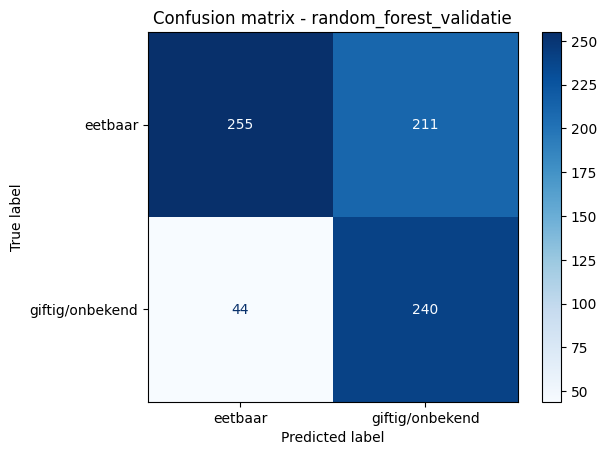

Evaluatie: gradient_boosting_validatie; drempel: 0.500


,accuracy,balanced_accuracy,precision_giftig,recall_giftig,f1_giftig,f2_giftig,roc_auc,average_precision
gradient_boosting_validatie,0.779,0.759,0.722,0.676,0.698,0.685,0.806,0.755


                 precision    recall  f1-score   support

        eetbaar       0.81      0.84      0.83       466
giftig/onbekend       0.72      0.68      0.70       284

       accuracy                           0.78       750
      macro avg       0.77      0.76      0.76       750
   weighted avg       0.78      0.78      0.78       750



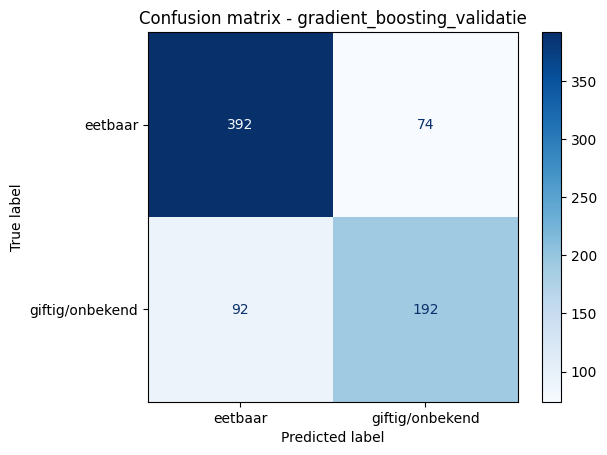

Evaluatie: extra_trees_validatie; drempel: 0.500


,accuracy,balanced_accuracy,precision_giftig,recall_giftig,f1_giftig,f2_giftig,roc_auc,average_precision
extra_trees_validatie,0.743,0.719,0.673,0.623,0.647,0.633,0.798,0.749


                 precision    recall  f1-score   support

        eetbaar       0.78      0.82      0.80       466
giftig/onbekend       0.67      0.62      0.65       284

       accuracy                           0.74       750
      macro avg       0.73      0.72      0.72       750
   weighted avg       0.74      0.74      0.74       750



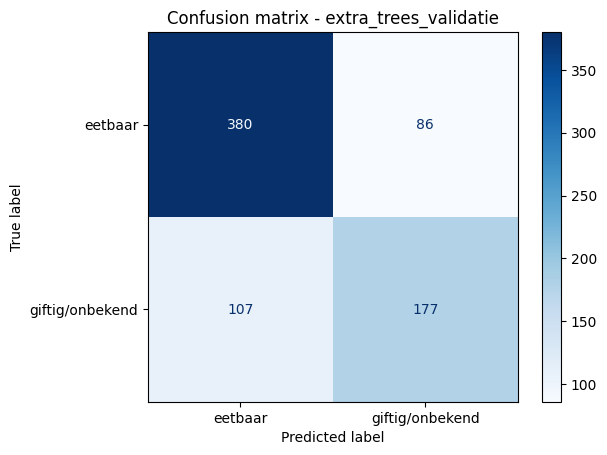

Evaluatie: logistic_regression_validatie; drempel: 0.500


,accuracy,balanced_accuracy,precision_giftig,recall_giftig,f1_giftig,f2_giftig,roc_auc,average_precision
logistic_regression_validatie,0.643,0.635,0.525,0.602,0.561,0.585,0.689,0.651


                 precision    recall  f1-score   support

        eetbaar       0.73      0.67      0.70       466
giftig/onbekend       0.52      0.60      0.56       284

       accuracy                           0.64       750
      macro avg       0.63      0.63      0.63       750
   weighted avg       0.65      0.64      0.65       750



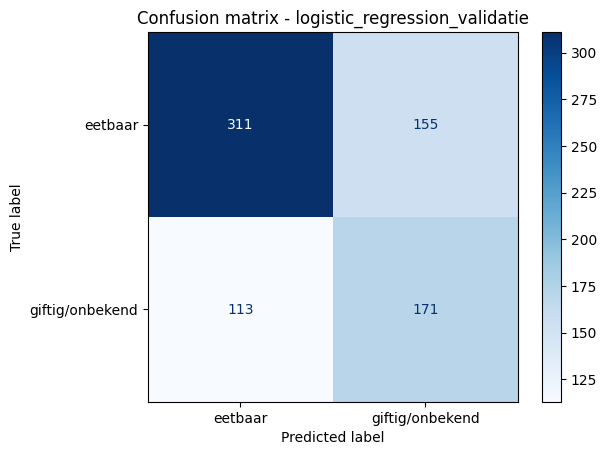

Evaluatie: stacking_standaard_validatie; drempel: 0.500


,accuracy,balanced_accuracy,precision_giftig,recall_giftig,f1_giftig,f2_giftig,roc_auc,average_precision
stacking_standaard_validatie,0.783,0.751,0.762,0.620,0.683,0.644,0.823,0.777


                 precision    recall  f1-score   support

        eetbaar       0.79      0.88      0.83       466
giftig/onbekend       0.76      0.62      0.68       284

       accuracy                           0.78       750
      macro avg       0.78      0.75      0.76       750
   weighted avg       0.78      0.78      0.78       750



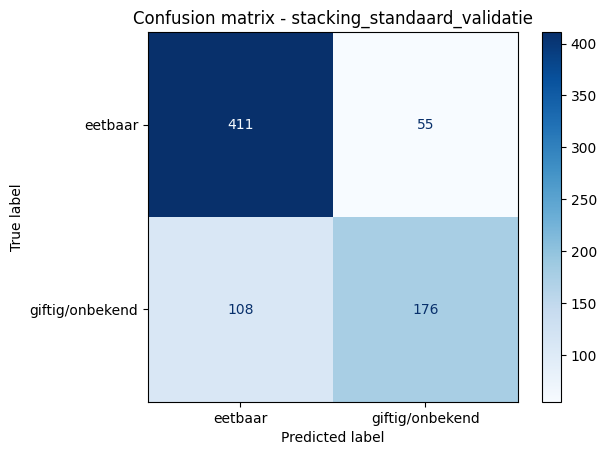

,accuracy,balanced_accuracy,precision_giftig,recall_giftig,f1_giftig,f2_giftig,roc_auc,average_precision
random_forest_validatie,0.660,0.696,0.532,0.845,0.653,0.756,0.815,0.763
gradient_boosting_validatie,0.779,0.759,0.722,0.676,0.698,0.685,0.806,0.755
stacking_standaard_validatie,0.783,0.751,0.762,0.620,0.683,0.644,0.823,0.777
extra_trees_validatie,0.743,0.719,0.673,0.623,0.647,0.633,0.798,0.749
logistic_regression_validatie,0.643,0.635,0.525,0.602,0.561,0.585,0.689,0.651


In [7]:
validation_metric_rows = []
for model_name, fitted_base_model in stacking_ensemble.named_estimators_.items():
    row = evaluate_classifier(
        fitted_base_model,
        X_validation,
        y_validation,
        f"{model_name}_validatie",
    )
    validation_metric_rows.append(row)

stacking_default_metrics = evaluate_classifier(
    stacking_ensemble,
    X_validation,
    y_validation,
    "stacking_standaard_validatie",
)
validation_metric_rows.append(stacking_default_metrics)

model_comparison = pd.DataFrame(validation_metric_rows).sort_values(
    ["f2_giftig", "accuracy"], ascending=False
)
display(model_comparison.style.format("{:.3f}"))

## 8. Accuracy- en veiligheidsdrempel op validatie

Omdat de testset nog volledig onaangeraakt is, gebruiken we de validatieset om twee kandidaten vast te leggen:

1. de drempel met de hoogste accuracy;
2. de drempel met de hoogste accuracy onder de eis van minimaal 85% recall voor giftig.

De uiteindelijke keuze moet vóór de eerste testevaluatie worden gemaakt.

,threshold,accuracy,balanced_accuracy,precision_giftig,recall_giftig,f2_giftig
hoogste_accuracy,0.530,0.788,0.753,0.783,0.609,0.637
veiligheid_min_85_recall,0.230,0.663,0.700,0.534,0.852,0.761


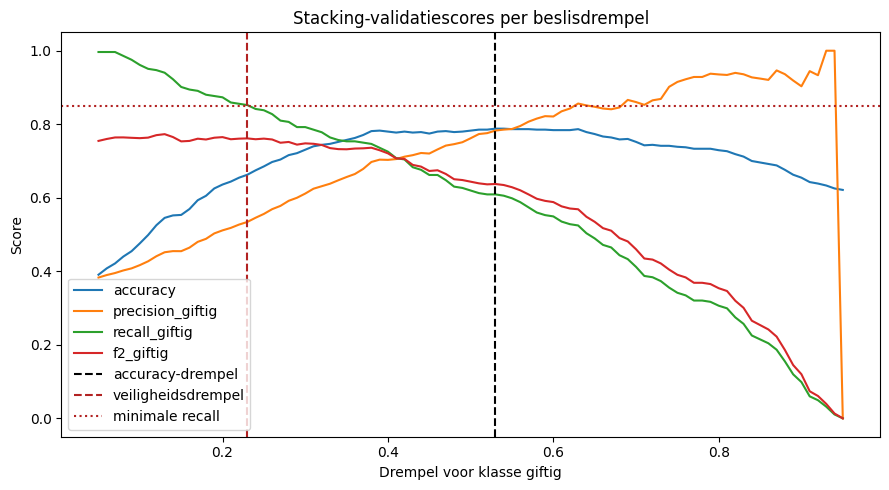

In [8]:
TARGET_POISONOUS_RECALL = 0.85
poisonous_index = list(stacking_ensemble.classes_).index(POISONOUS_LABEL)
validation_poisonous_probability = stacking_ensemble.predict_proba(
    X_validation
)[:, poisonous_index]

threshold_rows = []
for threshold in np.round(np.arange(0.05, 0.951, 0.01), 2):
    predictions = np.where(
        validation_poisonous_probability >= threshold,
        POISONOUS_LABEL,
        EDIBLE_LABEL,
    )
    threshold_rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_validation, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_validation, predictions),
        "precision_giftig": precision_score(
            y_validation, predictions, pos_label=POISONOUS_LABEL, zero_division=0
        ),
        "recall_giftig": recall_score(
            y_validation, predictions, pos_label=POISONOUS_LABEL, zero_division=0
        ),
        "f2_giftig": fbeta_score(
            y_validation,
            predictions,
            beta=2,
            pos_label=POISONOUS_LABEL,
            zero_division=0,
        ),
    })

threshold_results = pd.DataFrame(threshold_rows)
accuracy_choice = threshold_results.sort_values(
    ["accuracy", "balanced_accuracy", "f2_giftig"], ascending=False
).iloc[0]
eligible_safety = threshold_results.query(
    "recall_giftig >= @TARGET_POISONOUS_RECALL"
)
if eligible_safety.empty:
    raise RuntimeError("Geen drempel voldoet aan de minimale recall.")
safety_choice = eligible_safety.sort_values(
    ["accuracy", "precision_giftig", "f2_giftig"], ascending=False
).iloc[0]

accuracy_threshold = float(accuracy_choice["threshold"])
safety_threshold = float(safety_choice["threshold"])
threshold_choices = pd.DataFrame([
    accuracy_choice.rename("hoogste_accuracy"),
    safety_choice.rename("veiligheid_min_85_recall"),
])
display(threshold_choices.style.format("{:.3f}"))

plt.figure(figsize=(9, 5))
for metric in ["accuracy", "precision_giftig", "recall_giftig", "f2_giftig"]:
    plt.plot(threshold_results["threshold"], threshold_results[metric], label=metric)
plt.axvline(accuracy_threshold, color="black", linestyle="--", label="accuracy-drempel")
plt.axvline(safety_threshold, color="firebrick", linestyle="--", label="veiligheidsdrempel")
plt.axhline(TARGET_POISONOUS_RECALL, color="firebrick", linestyle=":", label="minimale recall")
plt.xlabel("Drempel voor klasse giftig")
plt.ylabel("Score")
plt.title("Stacking-validatiescores per beslisdrempel")
plt.legend()
plt.tight_layout()
plt.show()

### Gekozen drempelkandidaten evalueren

Dezelfde evaluatiefunctie toont confusion matrices en alle metrics voor beide kandidaten. Omdat de drempels op validatie zijn gekozen, zijn dit ontwikkelscores en nog geen definitieve prestaties.

Evaluatie: stacking_accuracy_drempel_validatie; drempel: 0.530


,accuracy,balanced_accuracy,precision_giftig,recall_giftig,f1_giftig,f2_giftig,roc_auc,average_precision
stacking_accuracy_drempel_validatie,0.788,0.753,0.783,0.609,0.685,0.637,0.823,0.777


                 precision    recall  f1-score   support

        eetbaar       0.79      0.90      0.84       466
giftig/onbekend       0.78      0.61      0.69       284

       accuracy                           0.79       750
      macro avg       0.79      0.75      0.76       750
   weighted avg       0.79      0.79      0.78       750



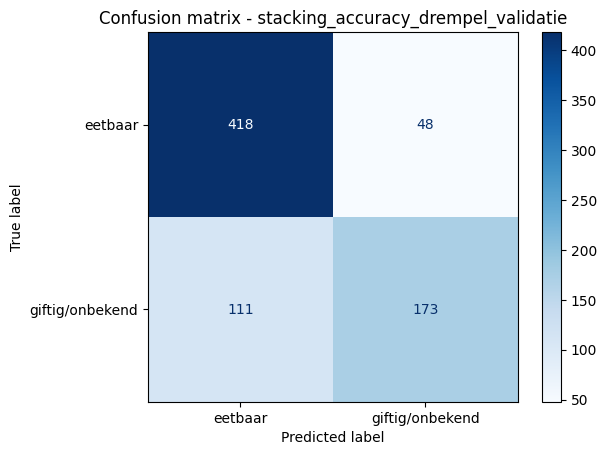

Evaluatie: stacking_veiligheidsdrempel_validatie; drempel: 0.230


,accuracy,balanced_accuracy,precision_giftig,recall_giftig,f1_giftig,f2_giftig,roc_auc,average_precision
stacking_veiligheidsdrempel_validatie,0.663,0.700,0.534,0.852,0.657,0.761,0.823,0.777


                 precision    recall  f1-score   support

        eetbaar       0.86      0.55      0.67       466
giftig/onbekend       0.53      0.85      0.66       284

       accuracy                           0.66       750
      macro avg       0.70      0.70      0.66       750
   weighted avg       0.74      0.66      0.66       750



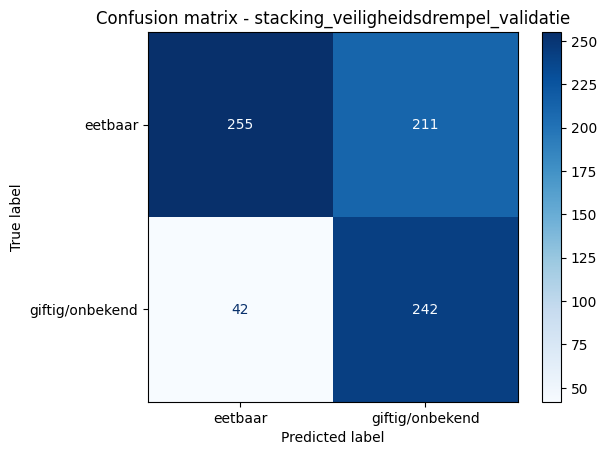

,accuracy,balanced_accuracy,precision_giftig,recall_giftig,f1_giftig,f2_giftig,roc_auc,average_precision
standaard_0.50,0.783,0.751,0.762,0.620,0.683,0.644,0.823,0.777
hoogste_accuracy,0.788,0.753,0.783,0.609,0.685,0.637,0.823,0.777
veiligheid_min_85_recall,0.663,0.700,0.534,0.852,0.657,0.761,0.823,0.777


In [9]:
stacking_accuracy_metrics = evaluate_classifier(
    stacking_ensemble,
    X_validation,
    y_validation,
    "stacking_accuracy_drempel_validatie",
    threshold=accuracy_threshold,
)
stacking_safety_metrics = evaluate_classifier(
    stacking_ensemble,
    X_validation,
    y_validation,
    "stacking_veiligheidsdrempel_validatie",
    threshold=safety_threshold,
)

stacking_threshold_comparison = pd.DataFrame([
    stacking_default_metrics.rename("standaard_0.50"),
    stacking_accuracy_metrics.rename("hoogste_accuracy"),
    stacking_safety_metrics.rename("veiligheid_min_85_recall"),
])
display(stacking_threshold_comparison.style.format("{:.3f}"))

## 9. Gewogen soft voting als tweede ensemble

Stacking optimaliseert log-loss via een meta-model. Als aanvullende controle zoeken we een transparante gewogen gemiddelde kans van Random Forest, Gradient Boosting en Extra Trees. We doorzoeken gewichten in stappen van 0,05 en dezelfde drempelreeks. Logistic Regression wordt hier niet meegenomen omdat het stacking-meta-model er een negatieve coëfficiënt aan gaf.

In [10]:
blend_model_names = ["random_forest", "gradient_boosting", "extra_trees"]
base_validation_probabilities = {}
for model_name in blend_model_names:
    fitted_model = stacking_ensemble.named_estimators_[model_name]
    model_classes = list(fitted_model.classes_)
    poisonous_class = POISONOUS_LABEL if POISONOUS_LABEL in model_classes else 1
    poisonous_index = model_classes.index(poisonous_class)
    base_validation_probabilities[model_name] = fitted_model.predict_proba(
        X_validation
    )[:, poisonous_index]

blend_frames = []
threshold_grid = np.round(np.arange(0.05, 0.951, 0.01), 2)
true_poisonous = np.asarray(y_validation == POISONOUS_LABEL)
WEIGHT_UNITS = 20
for random_forest_units in range(WEIGHT_UNITS + 1):
    for gradient_boosting_units in range(WEIGHT_UNITS - random_forest_units + 1):
        extra_trees_units = (
            WEIGHT_UNITS - random_forest_units - gradient_boosting_units
        )
        weights = {
            "random_forest": random_forest_units / WEIGHT_UNITS,
            "gradient_boosting": gradient_boosting_units / WEIGHT_UNITS,
            "extra_trees": extra_trees_units / WEIGHT_UNITS,
        }
        blended_probability = sum(
            weights[name] * base_validation_probabilities[name]
            for name in blend_model_names
        )
        prediction_matrix = (
            blended_probability[:, np.newaxis] >= threshold_grid[np.newaxis, :]
        )
        tp = (prediction_matrix & true_poisonous[:, np.newaxis]).sum(axis=0)
        fp = (prediction_matrix & ~true_poisonous[:, np.newaxis]).sum(axis=0)
        fn = (~prediction_matrix & true_poisonous[:, np.newaxis]).sum(axis=0)
        tn = (~prediction_matrix & ~true_poisonous[:, np.newaxis]).sum(axis=0)
        precision = np.divide(tp, tp + fp, out=np.zeros_like(tp, dtype=float), where=(tp + fp) > 0)
        recall = np.divide(tp, tp + fn, out=np.zeros_like(tp, dtype=float), where=(tp + fn) > 0)
        specificity = np.divide(tn, tn + fp, out=np.zeros_like(tn, dtype=float), where=(tn + fp) > 0)
        f2 = np.divide(
            5 * precision * recall,
            4 * precision + recall,
            out=np.zeros_like(precision),
            where=(4 * precision + recall) > 0,
        )
        blend_frames.append(pd.DataFrame({
            "random_forest_weight": weights["random_forest"],
            "gradient_boosting_weight": weights["gradient_boosting"],
            "extra_trees_weight": weights["extra_trees"],
            "threshold": threshold_grid,
            "accuracy": (tp + tn) / len(y_validation),
            "balanced_accuracy": (recall + specificity) / 2,
            "precision_giftig": precision,
            "recall_giftig": recall,
            "f2_giftig": f2,
        }))

blend_results = pd.concat(blend_frames, ignore_index=True)
blend_accuracy_choice = blend_results.sort_values(
    ["accuracy", "balanced_accuracy", "f2_giftig"], ascending=False
).iloc[0]
eligible_blends = blend_results.query(
    "recall_giftig >= @TARGET_POISONOUS_RECALL"
)
blend_safety_choice = eligible_blends.sort_values(
    ["accuracy", "precision_giftig", "f2_giftig"], ascending=False
).iloc[0]

blend_choices = pd.DataFrame([
    blend_accuracy_choice.rename("blend_hoogste_accuracy"),
    blend_safety_choice.rename("blend_veiligheid_min_85_recall"),
])
display(blend_choices.style.format("{:.3f}"))
print(blend_choices.round(3).to_string())

,random_forest_weight,gradient_boosting_weight,extra_trees_weight,threshold,accuracy,balanced_accuracy,precision_giftig,recall_giftig,f2_giftig
blend_hoogste_accuracy,0.700,0.050,0.250,0.590,0.791,0.759,0.777,0.627,0.652
blend_veiligheid_min_85_recall,0.700,0.050,0.250,0.460,0.669,0.706,0.540,0.856,0.766


                                random_forest_weight  gradient_boosting_weight  extra_trees_weight  threshold  accuracy  balanced_accuracy  precision_giftig  recall_giftig  f2_giftig
blend_hoogste_accuracy                           0.7                      0.05                0.25       0.59     0.791              0.759             0.777          0.627      0.652
blend_veiligheid_min_85_recall                   0.7                      0.05                0.25       0.46     0.669              0.706             0.540          0.856      0.766


### Soft-votingkandidaten evalueren

We tonen voor beide gekozen gewicht/drempel-combinaties dezelfde metrics en confusion matrix. Ook dit zijn ontwikkelscores op validatie, geen definitieve testresultaten.

Evaluatie: blend_accuracy_validatie; drempel: 0.590


,accuracy,balanced_accuracy,precision_giftig,recall_giftig,f1_giftig,f2_giftig,roc_auc,average_precision
blend_accuracy_validatie,0.791,0.759,0.777,0.627,0.694,0.652,0.818,0.768


accuracy             0.791
balanced_accuracy    0.759
precision_giftig     0.777
recall_giftig        0.627
f1_giftig            0.694
f2_giftig            0.652
roc_auc              0.818
average_precision    0.768


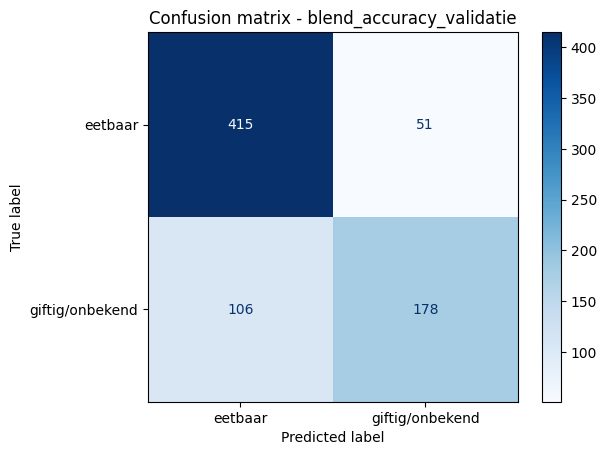

Evaluatie: blend_veiligheid_validatie; drempel: 0.460


,accuracy,balanced_accuracy,precision_giftig,recall_giftig,f1_giftig,f2_giftig,roc_auc,average_precision
blend_veiligheid_validatie,0.669,0.706,0.540,0.856,0.662,0.766,0.818,0.768


accuracy             0.669
balanced_accuracy    0.706
precision_giftig     0.540
recall_giftig        0.856
f1_giftig            0.662
f2_giftig            0.766
roc_auc              0.818
average_precision    0.768


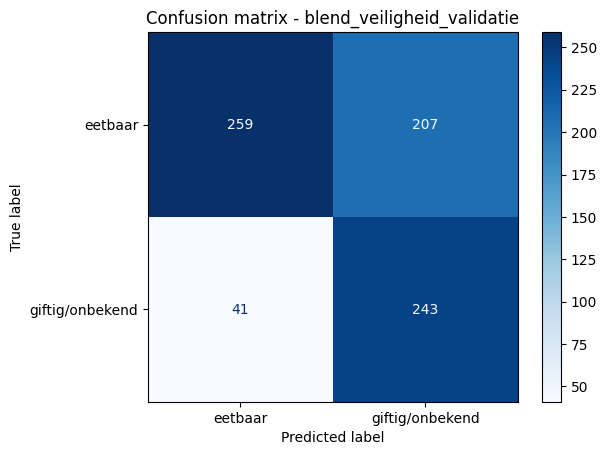

,accuracy,balanced_accuracy,precision_giftig,recall_giftig,f1_giftig,f2_giftig,roc_auc,average_precision
blend_veiligheid,0.669,0.706,0.540,0.856,0.662,0.766,0.818,0.768
stacking_veiligheid,0.663,0.700,0.534,0.852,0.657,0.761,0.823,0.777
blend_accuracy,0.791,0.759,0.777,0.627,0.694,0.652,0.818,0.768
stacking_accuracy,0.788,0.753,0.783,0.609,0.685,0.637,0.823,0.777


                     accuracy  balanced_accuracy  precision_giftig  recall_giftig  f1_giftig  f2_giftig  roc_auc  average_precision
blend_veiligheid        0.669              0.706             0.540          0.856      0.662      0.766    0.818              0.768
stacking_veiligheid     0.663              0.700             0.534          0.852      0.657      0.761    0.823              0.777
blend_accuracy          0.791              0.759             0.777          0.627      0.694      0.652    0.818              0.768
stacking_accuracy       0.788              0.753             0.783          0.609      0.685      0.637    0.823              0.777


In [11]:
def evaluate_probability_vector(probability, y_eval, split_name, threshold):
    predictions = np.where(
        probability >= threshold, POISONOUS_LABEL, EDIBLE_LABEL
    )
    metrics = pd.Series({
        "accuracy": accuracy_score(y_eval, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_eval, predictions),
        "precision_giftig": precision_score(
            y_eval, predictions, pos_label=POISONOUS_LABEL, zero_division=0
        ),
        "recall_giftig": recall_score(
            y_eval, predictions, pos_label=POISONOUS_LABEL, zero_division=0
        ),
        "f1_giftig": f1_score(
            y_eval, predictions, pos_label=POISONOUS_LABEL, zero_division=0
        ),
        "f2_giftig": fbeta_score(
            y_eval, predictions, beta=2, pos_label=POISONOUS_LABEL, zero_division=0
        ),
        "roc_auc": roc_auc_score(
            (y_eval == POISONOUS_LABEL).astype(int), probability
        ),
        "average_precision": average_precision_score(
            (y_eval == POISONOUS_LABEL).astype(int), probability
        ),
    }, name=split_name)
    print(f"Evaluatie: {split_name}; drempel: {threshold:.3f}")
    display(metrics.to_frame().T.style.format("{:.3f}"))
    print(metrics.round(3).to_string())
    ConfusionMatrixDisplay.from_predictions(
        y_eval, predictions,
        labels=[EDIBLE_LABEL, POISONOUS_LABEL],
        display_labels=["eetbaar", "giftig/onbekend"],
        cmap="Blues",
    )
    plt.title(f"Confusion matrix - {split_name}")
    plt.grid(False)
    plt.show()
    return metrics

def probabilities_for_blend(choice, probability_map):
    return sum(
        float(choice[f"{name}_weight"]) * probability_map[name]
        for name in blend_model_names
    )

blend_accuracy_probability = probabilities_for_blend(
    blend_accuracy_choice, base_validation_probabilities
)
blend_safety_probability = probabilities_for_blend(
    blend_safety_choice, base_validation_probabilities
)
blend_accuracy_metrics = evaluate_probability_vector(
    blend_accuracy_probability, y_validation, "blend_accuracy_validatie",
    float(blend_accuracy_choice["threshold"]),
)
blend_safety_metrics = evaluate_probability_vector(
    blend_safety_probability, y_validation, "blend_veiligheid_validatie",
    float(blend_safety_choice["threshold"]),
)

ensemble_candidate_comparison = pd.DataFrame([
    stacking_accuracy_metrics.rename("stacking_accuracy"),
    stacking_safety_metrics.rename("stacking_veiligheid"),
    blend_accuracy_metrics.rename("blend_accuracy"),
    blend_safety_metrics.rename("blend_veiligheid"),
]).sort_values(["f2_giftig", "accuracy"], ascending=False)
display(ensemble_candidate_comparison.style.format("{:.3f}"))
print(ensemble_candidate_comparison.round(3).to_string())

## 10. Wat leert het meta-model?

Bij binaire classificatie gebruikt het meta-model één kans per basismodel. Een grotere positieve coëfficiënt betekent dat de kans van dat basismodel de ensemblevoorspelling sterker richting giftig duwt. De coëfficiënten tonen modelgebruik, geen algemene kwaliteitsrangschikking.

,basismodel,coefficient
1,gradient_boosting,3.138922
2,extra_trees,2.495323
0,random_forest,1.830041
3,logistic_regression,-0.935500


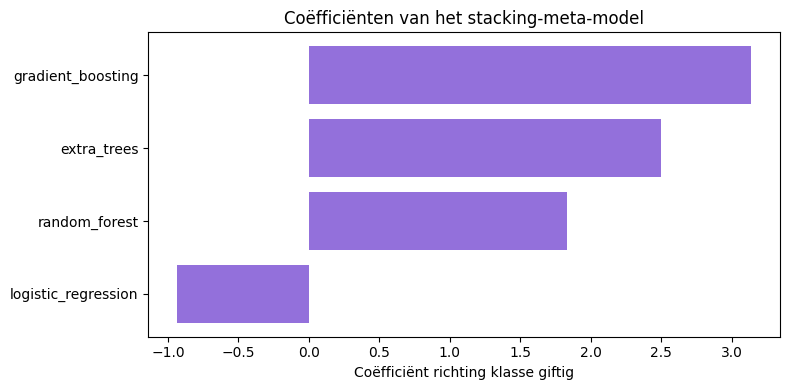

In [12]:
meta_coefficients = pd.DataFrame({
    "basismodel": [name for name, _ in stacking_ensemble.estimators],
    "coefficient": stacking_ensemble.final_estimator_.coef_[0],
}).sort_values("coefficient", ascending=False)

display(meta_coefficients)
plt.figure(figsize=(8, 4))
plt.barh(
    meta_coefficients["basismodel"][::-1],
    meta_coefficients["coefficient"][::-1],
    color="mediumpurple",
)
plt.title("Coëfficiënten van het stacking-meta-model")
plt.xlabel("Coëfficiënt richting klasse giftig")
plt.tight_layout()
plt.show()

## 11. Definitieve testset - vergrendeld

Kies eerst expliciet stacking of soft voting, plus de definitieve drempel en eventueel de drie blendgewichten. Vul die daarna hieronder in en zet `RUN_FINAL_TEST` één keer op `True`. Na het bekijken van de testscore worden geen model- of drempelkeuzes meer aangepast.

In [13]:
# Definitief bevroren op basis van validatie; de test blijft gesloten.
FINAL_APPROACH = "soft_voting"
FINAL_THRESHOLD = 0.46
FINAL_BLEND_WEIGHTS = {
    "random_forest": 0.70,
    "gradient_boosting": 0.05,
    "extra_trees": 0.25,
}

if RUN_FINAL_TEST and (FINAL_APPROACH is None or FINAL_THRESHOLD is None):
    raise ValueError("Kies eerst expliciet één aanpak en drempel.")
elif RUN_FINAL_TEST and FINAL_APPROACH == "stacking":
    test_metrics = evaluate_classifier(
        stacking_ensemble, X_test, y_test, "stacking_definitieve_test",
        threshold=FINAL_THRESHOLD,
    )
elif RUN_FINAL_TEST and FINAL_APPROACH == "soft_voting":
    if FINAL_BLEND_WEIGHTS is None:
        raise ValueError("Vul de drie definitieve blendgewichten in.")
    base_test_probabilities = {}
    for model_name in blend_model_names:
        fitted_model = stacking_ensemble.named_estimators_[model_name]
        model_classes = list(fitted_model.classes_)
        poisonous_class = POISONOUS_LABEL if POISONOUS_LABEL in model_classes else 1
        poisonous_index = model_classes.index(poisonous_class)
        base_test_probabilities[model_name] = fitted_model.predict_proba(
            X_test
        )[:, poisonous_index]
    final_probability = sum(
        FINAL_BLEND_WEIGHTS[name] * base_test_probabilities[name]
        for name in blend_model_names
    )
    test_metrics = evaluate_probability_vector(
        final_probability, y_test, "soft_voting_definitieve_test",
        threshold=FINAL_THRESHOLD,
    )
elif RUN_FINAL_TEST:
    raise ValueError(f"Onbekende FINAL_APPROACH: {FINAL_APPROACH}")
else:
    print("Testset niet geëvalueerd: kies eerst de definitieve ensemble-drempel.")

Testset niet geëvalueerd: kies eerst de definitieve ensemble-drempel.


## 12. Beslispunt

Vergelijk de stackingresultaten met de eerder gemeten Random Forest- en Gradient Boosting-resultaten. Bevries pas daarna het gekozen model en de gekozen drempel. De testset wordt slechts één keer gebruikt voor de definitieve, onbevooroordeelde evaluatie.